# Topic Model

## Installation

In [1]:
# !pip install bertopic

## Loading Dataset

In [1]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd

df = pd.read_csv('food.csv')
df.head()

,名稱,網址,電話,行政區,AreaCode,地址,介紹
0,新竹水潤餅,https://www.facebook.com/profile.php?id=100063...,(03)5243708,北區,10018020,成功路326號,外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹...
1,彭成珍餅舖,https://www.pengpastry.com.tw/,(03)5224877,北區,10018020,西安街5巷21號,推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人...
2,淵明餅舖,http://www.yuanming.com.tw/,0952170115,北區,10018020,中山路112號,推薦菜色：肉燥水蒸鹹蛋糕、風味芋頭餅、冰立方吐司；滷肉燥搭鬆軟蛋糕，在口中會撞出怎樣的火花？...
3,新復珍商行,https://www.hfj.com.tw/,(03)5222205,北區,10018020,北門街6號,推薦菜色：竹塹餅、柴梳餅、核桃酥餅、水蒸蛋糕、美祿柑、綠豆椪，有一種餅，作家焦桐說它的滋味是...
4,光華冰果店,https://www.facebook.com/kwanhua35,(03)5322318,北區,10018020,光華東街35號,推薦菜色：綜合冰、四果湯、銀耳蓮子湯，在許多新竹人心中，「光華」是記憶中陪伴成長的一家老冰菓...


In [2]:
docs = df['介紹'].tolist()
docs[:2]

['外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹人從小吃到大的「古早零嘴」，早期新竹還有多家製作水潤餅的店，然而隨著時代變遷與利潤降低，這簡單樸實的老味道也漸漸凋零，如今新竹只剩下「德龍商行」仍持續販售。德龍商行的二代老闆楊水龍，從國中開始跟父親學做水潤餅，兩代經營至今已超過50年。水潤餅外型圓扁，形狀不太規則，餅皮有斑狀的火痕，原料一如其單純的外型，只有麵粉、水、糖、鹽和肉桂粉；因為不含人工添加物和防腐劑，只能保存3至4天，冷凍能保存半年。楊老闆說：「外地類似這樣的餅都做得像山東大餅一樣，又乾又硬，跟我們的水潤餅不同。」水潤餅的水份較多且軟軟的，類似台語的「水軟水軟」，因而得名。咬一口水潤餅就會發現它不僅軟Q易入口，還帶著一點鹹甜麵粉香的濕潤口感，與傳統大餅的酥脆完全不同，成了早期老人和小孩最愛的點心。撕開餅皮，大大小小的氣孔，淡淡的肉桂香從中散開，滋味雖不濃郁，卻引人入勝，適合作茶點。說起自家水潤餅之所以成為新竹特色美食之一，楊老闆笑說：「因為城隍爺有保佑」。原來大約40多年前，一群在城隍廟服務的志工阿嬤將水潤餅做為獻給城隍爺的供品，此後水潤餅便逐漸興起，更因此成為「平安餅」；每逢農曆七月中元節，新竹都城隍廟范謝將軍遶境出巡時，都會將水潤餅用紅線穿成串，綁在神將身上，供信眾求食保平安，「用水潤餅作為平安餅」的風俗也成為新竹獨一無二的文化傳統。隨著飲食習慣的改變，水潤餅逐漸被人遺忘，年輕一輩新竹人，對這種廟會食品恐怕也僅存朦朧印象。市府在推動「新竹好物」美食復興計畫時，市長林智堅想起了水潤餅，特別推薦，希望更多人認識新竹在地獨特的日常美味。現今年輕人也開發出許多創意吃法，例如把這款古早味零嘴夾上餡料，包上肉末、荷包蛋，或者塗上果醬、咖哩，起司，都有令人驚豔的口感。',
 '推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人可能不知道狹窄的西安街巷裡，有一家傳承三代的傳統糕餅老舖─彭成珍。80多年前，彭成珍阿公以製作傳統糕餅維生，當時賣竹塹餅、柴梳餅等漢餅，每到節慶，也做些應景糕點，像新年的寸棗、中秋月餅、初一十五拜拜的紅龜粿等，主要批發給柑仔店，建立一定口碑。第三代的彭垂明原服務銀行界，從小跟在父母身邊幫忙，每逢中秋大月製餅人手不足時，總得請假幫忙，每見父母常沒日沒夜忙碌，一

## Getting embeddings and training the model

There are multiple models we can use to turn the documents into embeddings:
```
paraphrase-multilingual-MiniLM-L12-v2
paraphrase-multilingual-mpnet-base-v2
distiluse-base-multilingual-cased-v2
xlm-r-bert-base-nli-stsb-mean-tokens
```

In [3]:
# Get embeddings
sentence_model = SentenceTransformer("distiluse-base-multilingual-cased-v2") # 
embeddings = sentence_model.encode(docs, show_progress_bar=True)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
topic_model = BERTopic(language="multilingual",
                       min_topic_size=2, # At least 20 documents per topic
                       # nr_topics=10, # This will specify topic reduction
                       verbose=True)
topics, probs = topic_model.fit_transform(docs, embeddings)

2026-05-13 21:31:35,929 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-05-13 21:31:41,579 - BERTopic - Dimensionality - Completed ✓
2026-05-13 21:31:41,583 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 21:31:41,619 - BERTopic - Cluster - Completed ✓
2026-05-13 21:31:41,627 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 21:31:41,652 - BERTopic - Representation - Completed ✓


The training process will yield two outputs:
1. `topics` gives you the topic number of each document, as a list
2. `probs` gives you the probability of the document belonging to the topic (higher number means the model is very confident)

In [41]:
# The easiest way to combine the result back to the dataset is to...
df['topic'] = topics

In [42]:
df.head()

,名稱,網址,電話,行政區,AreaCode,地址,介紹,topic
0,新竹水潤餅,https://www.facebook.com/profile.php?id=100063...,(03)5243708,北區,10018020,成功路326號,外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹...,1
1,彭成珍餅舖,https://www.pengpastry.com.tw/,(03)5224877,北區,10018020,西安街5巷21號,推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人...,1
2,淵明餅舖,http://www.yuanming.com.tw/,0952170115,北區,10018020,中山路112號,推薦菜色：肉燥水蒸鹹蛋糕、風味芋頭餅、冰立方吐司；滷肉燥搭鬆軟蛋糕，在口中會撞出怎樣的火花？...,1
3,新復珍商行,https://www.hfj.com.tw/,(03)5222205,北區,10018020,北門街6號,推薦菜色：竹塹餅、柴梳餅、核桃酥餅、水蒸蛋糕、美祿柑、綠豆椪，有一種餅，作家焦桐說它的滋味是...,1
4,光華冰果店,https://www.facebook.com/kwanhua35,(03)5322318,北區,10018020,光華東街35號,推薦菜色：綜合冰、四果湯、銀耳蓮子湯，在許多新竹人心中，「光華」是記憶中陪伴成長的一家老冰菓...,0


## Interpreting the model

In [5]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7,-1_推薦菜色_不過_老王記_鳳梨酥,"[推薦菜色, 不過, 老王記, 鳳梨酥, 豔麗, 阿富魯肉飯, 薪石窯, 小籠包, 魯肉飯,...",[推薦菜色：小籠包、水餃、綠豆稀飯，老王記的水餃每天現包現賣，由黃家兩姊妹負責，兩人一個半小...
1,0,15,0_推薦菜色_咕嚕嚕_北門炸粿_曾經,"[推薦菜色, 咕嚕嚕, 北門炸粿, 曾經, 炸醬麵, 璽子, 此外, 肉絲, 榮記, 榨菜肉絲麵]",[推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名...
2,1,9,1_推薦菜色_花生糖派對_竹塹餅_柴梳餅,"[推薦菜色, 花生糖派對, 竹塹餅, 柴梳餅, 客家小肉餅, 紅油抄手, 發呆的雞, 蔥酥餅...",[推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般...
3,2,5,2_鴨肉許_推薦菜色_狀元雞_草根廚房,"[鴨肉許, 推薦菜色, 狀元雞, 草根廚房, 草根鍋餅, 川丸子, 炒鴨血, 緣自一場暖心意...",[推薦菜色：鴨香飯、燻鴨切盤、炒鴨血，2016年以一道鴨香飯入選「竹好呷」，深獲媒體推薦的「...
4,3,4,3_太陽飯_魚條_漁香_骨仔肉魚丸湯,"[太陽飯, 魚條, 漁香, 骨仔肉魚丸湯, 泡菜, 漁香甜不辣, 來喲, 墨魚香腸, 推薦菜...",[推薦菜色：墨魚香腸、烤二層肉、炸軟絲，這間店簡單得只剩下美味。天香海鮮店老闆陳清文有如鄉間...
5,4,4,4_麻油松阪豬_不過_黑米糕_紅燒魚皮,"[麻油松阪豬, 不過, 黑米糕, 紅燒魚皮, 烤排骨, 古早味蚵仔煎, 花雕雞, 鹹蛋苦瓜,...",[推薦菜色：招牌烤蚵、私房牛肋條、豆豉鮮蚵飯，看似荒涼的台一線省道上，隱藏一處新竹人即使花上...
6,5,3,5_檸檬塔_可麗露_檸檬生乳酪蛋糕_金磚布丁,"[檸檬塔, 可麗露, 檸檬生乳酪蛋糕, 金磚布丁, 咖啡豆, 周義翔說, 推薦菜色, 煒哥希...",[推薦菜色：義式咖啡、單品咖啡、手作甜點（檸檬系列、核桃布朗尼），簡約文青風的墨咖啡，是許多...


In [6]:
topic_model.get_topic(0)

[('推薦菜色', np.float64(0.03243990510872863)),
 ('咕嚕嚕', np.float64(0.021491365017114617)),
 ('北門炸粿', np.float64(0.01801974417048612)),
 ('曾經', np.float64(0.014315734973553028)),
 ('炸醬麵', np.float64(0.014315734973553028)),
 ('璽子', np.float64(0.010297922124538277)),
 ('此外', np.float64(0.010297922124538277)),
 ('肉絲', np.float64(0.010297922124538277)),
 ('榮記', np.float64(0.010297922124538277)),
 ('榨菜肉絲麵', np.float64(0.010297922124538277))]

In [7]:
topic_model.get_document_info(docs)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹...,1,1_推薦菜色_花生糖派對_竹塹餅_柴梳餅,"[推薦菜色, 花生糖派對, 竹塹餅, 柴梳餅, 客家小肉餅, 紅油抄手, 發呆的雞, 蔥酥餅...",[推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般...,推薦菜色 - 花生糖派對 - 竹塹餅 - 柴梳餅 - 客家小肉餅 - 紅油抄手 - 發呆的雞...,0.674939,False
1,推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人...,1,1_推薦菜色_花生糖派對_竹塹餅_柴梳餅,"[推薦菜色, 花生糖派對, 竹塹餅, 柴梳餅, 客家小肉餅, 紅油抄手, 發呆的雞, 蔥酥餅...",[推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般...,推薦菜色 - 花生糖派對 - 竹塹餅 - 柴梳餅 - 客家小肉餅 - 紅油抄手 - 發呆的雞...,1.000000,True
2,推薦菜色：肉燥水蒸鹹蛋糕、風味芋頭餅、冰立方吐司；滷肉燥搭鬆軟蛋糕，在口中會撞出怎樣的火花？...,1,1_推薦菜色_花生糖派對_竹塹餅_柴梳餅,"[推薦菜色, 花生糖派對, 竹塹餅, 柴梳餅, 客家小肉餅, 紅油抄手, 發呆的雞, 蔥酥餅...",[推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般...,推薦菜色 - 花生糖派對 - 竹塹餅 - 柴梳餅 - 客家小肉餅 - 紅油抄手 - 發呆的雞...,1.000000,True
3,推薦菜色：竹塹餅、柴梳餅、核桃酥餅、水蒸蛋糕、美祿柑、綠豆椪，有一種餅，作家焦桐說它的滋味是...,1,1_推薦菜色_花生糖派對_竹塹餅_柴梳餅,"[推薦菜色, 花生糖派對, 竹塹餅, 柴梳餅, 客家小肉餅, 紅油抄手, 發呆的雞, 蔥酥餅...",[推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般...,推薦菜色 - 花生糖派對 - 竹塹餅 - 柴梳餅 - 客家小肉餅 - 紅油抄手 - 發呆的雞...,0.594512,False
4,推薦菜色：綜合冰、四果湯、銀耳蓮子湯，在許多新竹人心中，「光華」是記憶中陪伴成長的一家老冰菓...,0,0_推薦菜色_咕嚕嚕_北門炸粿_曾經,"[推薦菜色, 咕嚕嚕, 北門炸粿, 曾經, 炸醬麵, 璽子, 此外, 肉絲, 榮記, 榨菜肉絲麵]",[推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名...,推薦菜色 - 咕嚕嚕 - 北門炸粿 - 曾經 - 炸醬麵 - 璽子 - 此外 - 肉絲 - ...,1.000000,False
5,推薦菜色：陽春麵、榨菜肉絲麵、滷味拼盤，樹林頭麵店是時代的座標，讓過去的記憶降落，讓現在的人...,0,0_推薦菜色_咕嚕嚕_北門炸粿_曾經,"[推薦菜色, 咕嚕嚕, 北門炸粿, 曾經, 炸醬麵, 璽子, 此外, 肉絲, 榮記, 榨菜肉絲麵]",[推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名...,推薦菜色 - 咕嚕嚕 - 北門炸粿 - 曾經 - 炸醬麵 - 璽子 - 此外 - 肉絲 - ...,1.000000,False
6,推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名老...,0,0_推薦菜色_咕嚕嚕_北門炸粿_曾經,"[推薦菜色, 咕嚕嚕, 北門炸粿, 曾經, 炸醬麵, 璽子, 此外, 肉絲, 榮記, 榨菜肉絲麵]",[推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名...,推薦菜色 - 咕嚕嚕 - 北門炸粿 - 曾經 - 炸醬麵 - 璽子 - 此外 - 肉絲 - ...,0.801074,True
7,推薦菜色：原味甜不辣、鹽酥甜不辣、綜合飯、牛蒡甜不辣，深受在地人喜愛的「漁香甜不辣」，以新鮮...,3,3_太陽飯_魚條_漁香_骨仔肉魚丸湯,"[太陽飯, 魚條, 漁香, 骨仔肉魚丸湯, 泡菜, 漁香甜不辣, 來喲, 墨魚香腸, 推薦菜...",[推薦菜色：墨魚香腸、烤二層肉、炸軟絲，這間店簡單得只剩下美味。天香海鮮店老闆陳清文有如鄉間...,太陽飯 - 魚條 - 漁香 - 骨仔肉魚丸湯 - 泡菜 - 漁香甜不辣 - 來喲 - 墨魚香...,0.835794,True
8,推薦菜色：古早味蚵仔煎、烤排骨、紅燒魚皮、黑米糕，位於民富國小對面的竹樂食堂，是老牌熱炒店，...,4,4_麻油松阪豬_不過_黑米糕_紅燒魚皮,"[麻油松阪豬, 不過, 黑米糕, 紅燒魚皮, 烤排骨, 古早味蚵仔煎, 花雕雞, 鹹蛋苦瓜,...",[推薦菜色：招牌烤蚵、私房牛肋條、豆豉鮮蚵飯，看似荒涼的台一線省道上，隱藏一處新竹人即使花上...,麻油松阪豬 - 不過 - 黑米糕 - 紅燒魚皮 - 烤排骨 - 古早味蚵仔煎 - 花雕雞 -...,1.000000,True
9,推薦菜色：藥膳燒酒烏骨雞、金錢蝦、里肌糖醋肉、墨魚香腸，台灣到處都有燒酒雞，但新竹市「蔡記雞...,4,4_麻油松阪豬_不過_黑米糕_紅燒魚皮,"[麻油松阪豬, 不過, 黑米糕, 紅燒魚皮, 烤排骨, 古早味蚵仔煎, 花雕雞, 鹹蛋苦瓜,...",[推薦菜色：招牌烤蚵、私房牛肋條、豆豉鮮蚵飯，看似荒涼的台一線省道上，隱藏一處新竹人即使花上...,麻油松阪豬 - 不過 - 黑米糕 - 紅燒魚皮 - 烤排骨 - 古早味蚵仔煎 - 花雕雞 -...,1.000000,False


In [ ]:
# # This is how you save and load a topic model
# topic_model.save("my_model", serialization="pickle")
# loaded_model = BERTopic.load("MaartenGr/BERTopic_Wikipedia")

## Visualizations

The first task of interpreting a topic model is often assigning a label to each topic.

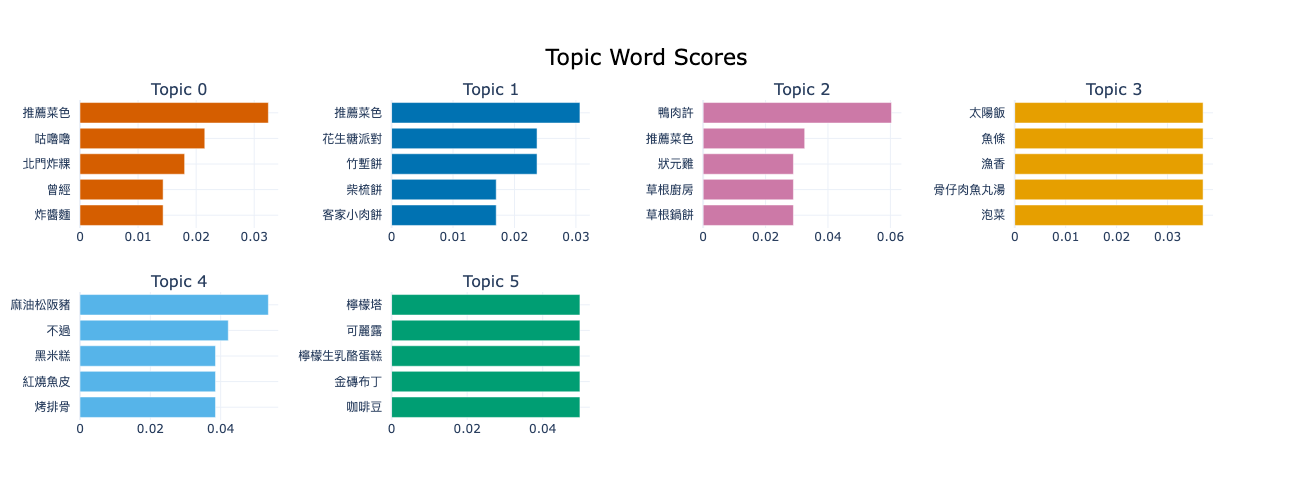

In [17]:
topic_model.visualize_barchart()

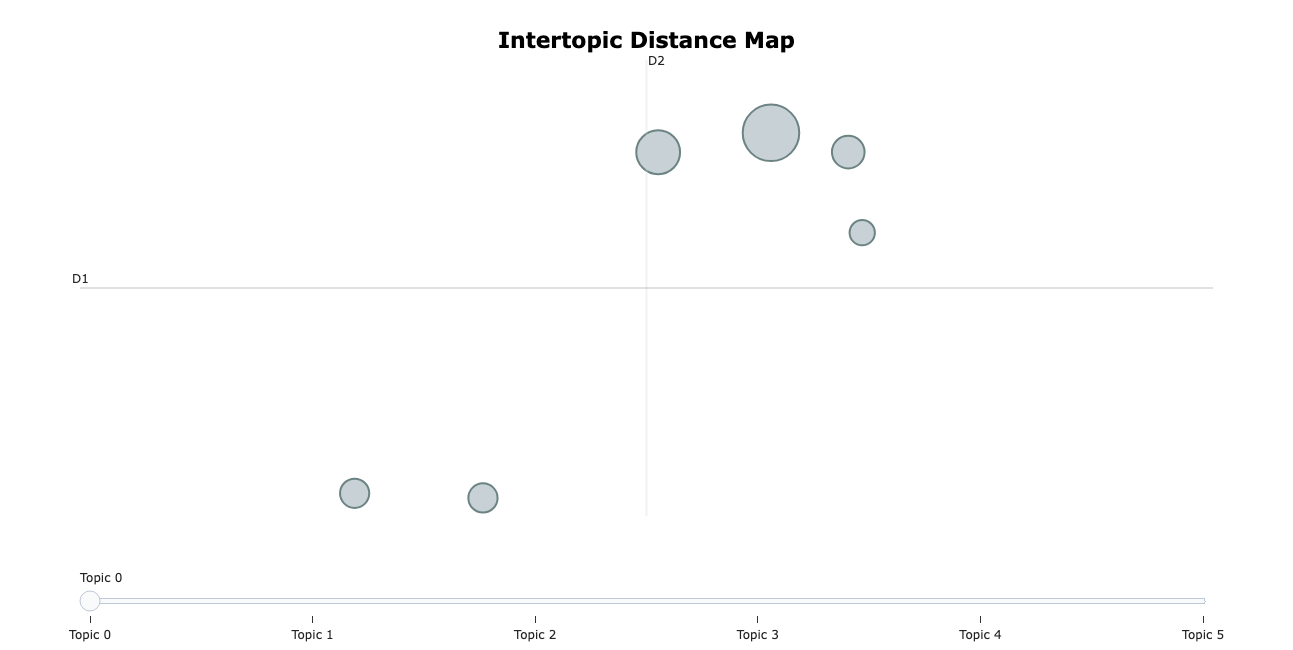

In [8]:
fig_topics = topic_model.visualize_topics()
fig_topics

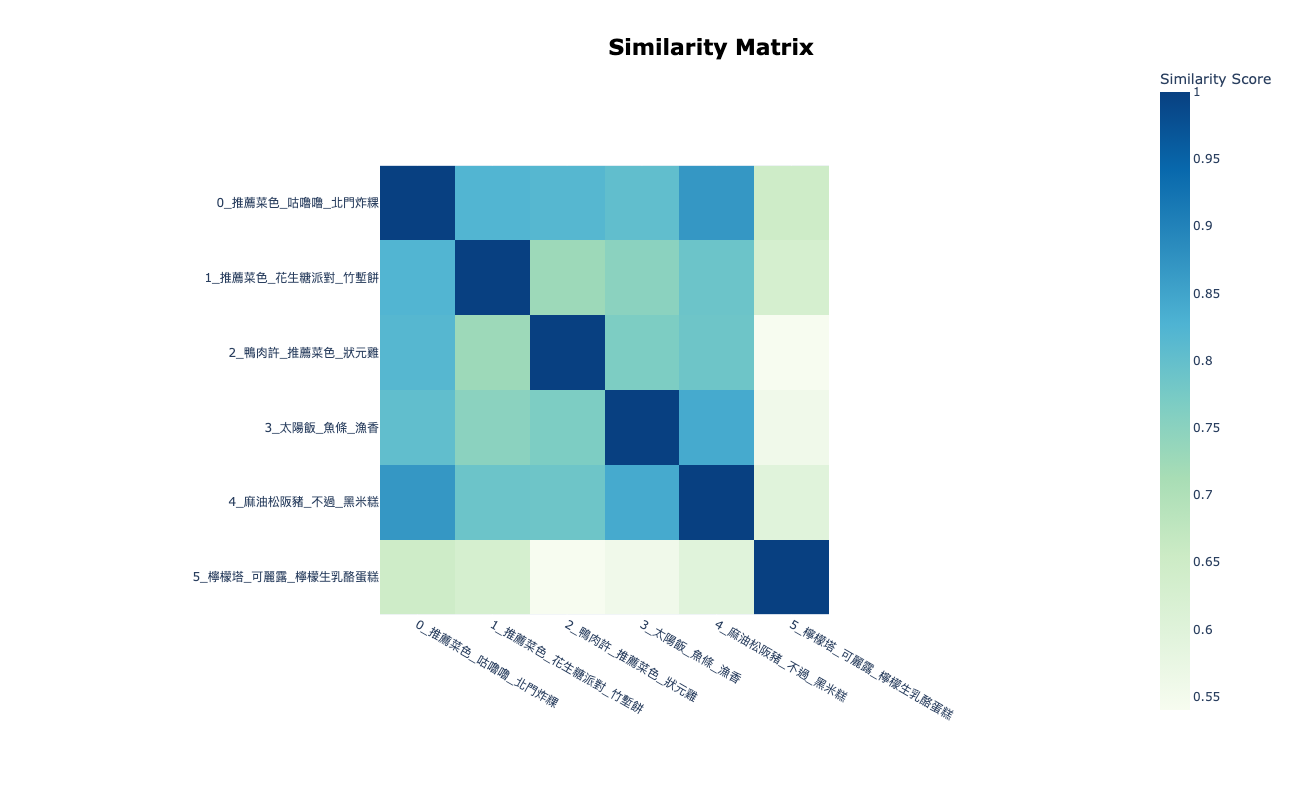

In [12]:
topic_model.visualize_heatmap()

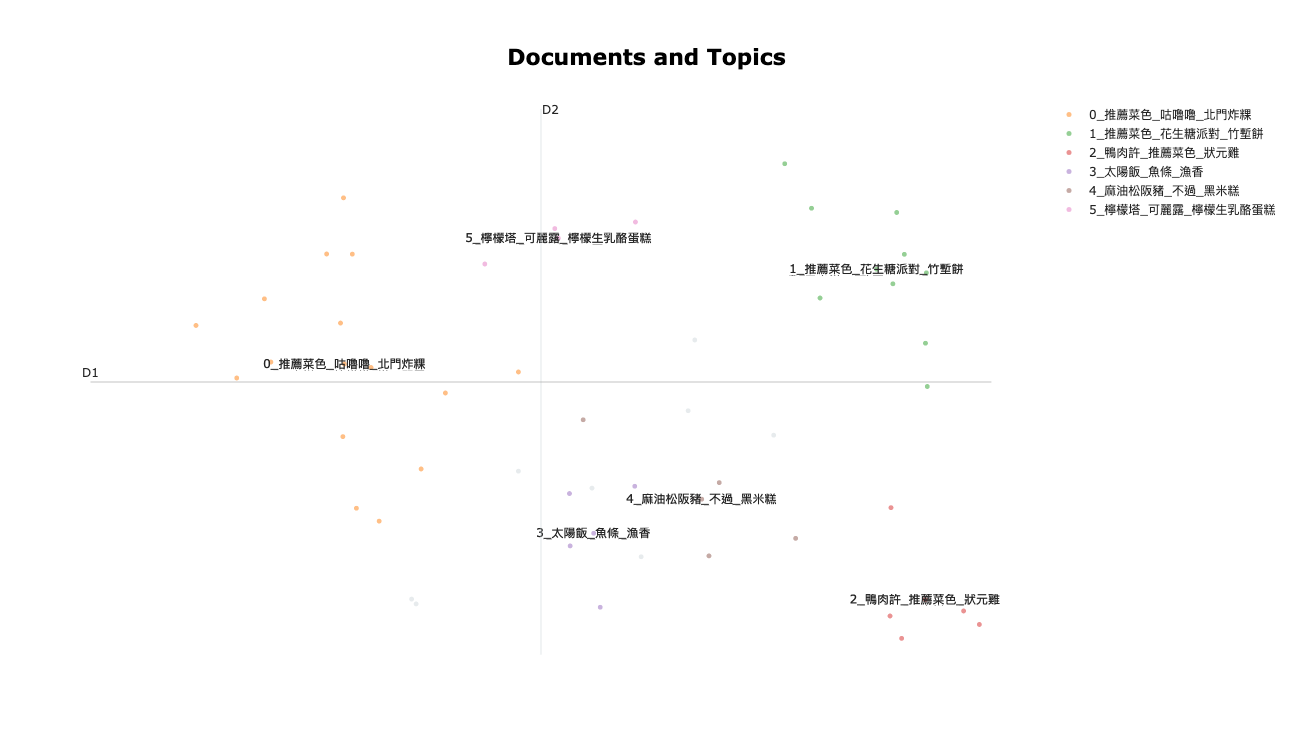

In [16]:
from umap import UMAP
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings)

## Validation

Topic modelling is exploratory, so validation is a design requirement rather than an afterthought. 

The simplest way is:
1. sample a subset of documents
2. ask coder(s) to annotate them based on topic label
3. calculate intercoder reliability between the results from the topic model and the manual annotation

In [36]:
# Making a sample dataset for manual validation.

doc_df = topic_model.get_document_info(docs)

sample_df = doc_df.groupby('Topic').sample(n=3)
sample_df = sample_df.sample(frac=1)
sample_df = sample_df[sample_df.Topic != -1]
sample_df = sample_df[['Document','Topic']]
sample_df

,Document,Topic
19,推薦菜色：金磚布丁、可麗露、手沖精品咖啡「影咖啡」主打攝影主題與手作甜點，店內每個角落都精心...,5
38,推薦菜色：招牌魯肉飯、太陽飯、泡菜、小魚辣椒、手工魚羹，「好東西得經得起挑戰！」老闆鄭明枝開...,3
6,推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名老...,0
28,推薦菜色：咖啡豆、手沖咖啡、流淚鬆餅，「接軌國際，新鮮直達」是直達咖啡最初命名的初衷。直達，...,5
35,推薦菜色：當歸鴨麵線、當歸豬腳麵線、當歸滷味拼盤，明亮燈光與潔淨店面，南門當歸鴨和你想像的傳...,2
42,推薦菜色：驕傲的咖哩(PIZZA)、季節限定PIZZA，Luau，是夏威夷原住民語，意指在花...,1
46,推薦菜色：招牌烤蚵、私房牛肋條、豆豉鮮蚵飯，看似荒涼的台一線省道上，隱藏一處新竹人即使花上大...,4
9,推薦菜色：藥膳燒酒烏骨雞、金錢蝦、里肌糖醋肉、墨魚香腸，台灣到處都有燒酒雞，但新竹市「蔡記雞...,4
43,推薦菜色：麻糬餅、客家紅豆手工麻糬、客家小肉餅，傳統手做麻糬，融合客家意象與風味，嘗一口，會...,1
8,推薦菜色：古早味蚵仔煎、烤排骨、紅燒魚皮、黑米糕，位於民富國小對面的竹樂食堂，是老牌熱炒店，...,4


In [37]:
sample_df.to_csv('sample.csv')

## Some last words

Check this out for more functions: https://maartengr.github.io/BERTopic/